Nome: Tiago Luterbach de Medeiros

Trabalho 3 para a disciplina de Topicos especiais em Engenharia de Telecomunicaoes

Fiz um codigo que o objetivo é prever a posição final de um piloto em uma corrida de Fórmula 1 da temporada de 2024 com base em sua posição de largada (grid), a pontuação atual no campeonato e a idade do piloto.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Base de Dados Real de Pilotos 2024 (Nome, Idade, Exp, Pontos Finais) ---
# Fontes: Autosport, F1.com (Temporada 2024 Final)
pilotos_real_2024 = [
    {'nome': 'Max Verstappen', 'idade': 27, 'exp_anos': 10, 'pontos_2024': 437, 'time_tier': 1},
    {'nome': 'Lando Norris',   'idade': 25, 'exp_anos': 6,  'pontos_2024': 374, 'time_tier': 1},
    {'nome': 'Charles Leclerc','idade': 27, 'exp_anos': 7,  'pontos_2024': 356, 'time_tier': 1},
    {'nome': 'Oscar Piastri',  'idade': 23, 'exp_anos': 2,  'pontos_2024': 292, 'time_tier': 1},
    {'nome': 'Carlos Sainz',   'idade': 30, 'exp_anos': 10, 'pontos_2024': 290, 'time_tier': 2},
    {'nome': 'George Russell', 'idade': 26, 'exp_anos': 6,  'pontos_2024': 245, 'time_tier': 2},
    {'nome': 'Lewis Hamilton', 'idade': 39, 'exp_anos': 18, 'pontos_2024': 223, 'time_tier': 2},
    {'nome': 'Sergio Perez',   'idade': 34, 'exp_anos': 14, 'pontos_2024': 152, 'time_tier': 2},
    {'nome': 'Fernando Alonso','idade': 43, 'exp_anos': 21, 'pontos_2024': 62,  'time_tier': 3},
    {'nome': 'Lance Stroll',   'idade': 26, 'exp_anos': 8,  'pontos_2024': 24,  'time_tier': 3},
    {'nome': 'Nico Hulkenberg','idade': 37, 'exp_anos': 12, 'pontos_2024': 24,  'time_tier': 3},
    {'nome': 'Yuki Tsunoda',   'idade': 24, 'exp_anos': 4,  'pontos_2024': 22,  'time_tier': 3},
    {'nome': 'Pierre Gasly',   'idade': 28, 'exp_anos': 8,  'pontos_2024': 26,  'time_tier': 4}, 
    {'nome': 'Esteban Ocon',   'idade': 28, 'exp_anos': 8,  'pontos_2024': 23,  'time_tier': 4},
    {'nome': 'Kevin Magnussen','idade': 32, 'exp_anos': 10, 'pontos_2024': 14,  'time_tier': 4},
    {'nome': 'Alex Albon',     'idade': 28, 'exp_anos': 5,  'pontos_2024': 12,  'time_tier': 4},
    {'nome': 'Daniel Ricciardo','idade': 35, 'exp_anos': 14, 'pontos_2024': 12, 'time_tier': 4},
    {'nome': 'Franco Colapinto','idade': 21, 'exp_anos': 1,  'pontos_2024': 5,   'time_tier': 5},
    {'nome': 'Zhou Guanyu',    'idade': 25, 'exp_anos': 3,  'pontos_2024': 4,   'time_tier': 5},
    {'nome': 'Valtteri Bottas','idade': 35, 'exp_anos': 12, 'pontos_2024': 0,   'time_tier': 5}
]

# --- 2. Gerando o Dataset de Treinamento (Simulação de 10 Corridas) ---
# Vamos criar dados para 10 corridas (aprox 200 linhas) baseados nesses perfis reais.
dados_corridas = []
np.random.seed(2024) # Semente para reproduzir os mesmos resultados

for corrida in range(1, 11): # 10 corridas
    # Embaralha os pilotos para criar um Grid de Largada aleatório,
    # mas ponderado pelo 'time_tier' (carros melhores largam melhor)

    # Adicionamos um fator de aleatoriedade no grid
    grid_base = sorted(pilotos_real_2024, key=lambda x: x['pontos_2024'] + np.random.randint(-100, 100), reverse=True)

    for posicao, piloto in enumerate(grid_base, 1):
        # A posição final é influenciada pela largada e pelo carro (pontos), com imprevistos (ruído)
        # Lógica: Grid + (Fator Carro Inverso) + Sorte

        fator_habilidade = (500 - piloto['pontos_2024']) / 50 # Quanto mais pontos, menor esse número (chega mais à frente)
        posicao_final_estimada = (posicao * 0.5) + fator_habilidade + np.random.normal(0, 3)

        # Limitar entre 1 e 20
        posicao_final = int(np.clip(posicao_final_estimada, 1, 20))

        linha = {
            'piloto_id': piloto['nome'], # Apenas para referência, vamos remover no treino
            'idade': piloto['idade'],
            'experiencia': piloto['exp_anos'],
            'pontos_atualmente': piloto['pontos_2024'],
            'posicao_largada': posicao,
            'posicao_final': posicao_final
        }
        dados_corridas.append(linha)

df = pd.DataFrame(dados_corridas)

print("Amostra do Dataset Gerado (Dados Reais 2024):")
display(df.head())

Amostra do Dataset Gerado (Dados Reais 2024):


,piloto_id,idade,experiencia,pontos_atualmente,posicao_largada,posicao_final
0,Max Verstappen,27,10,437,1,1
1,Charles Leclerc,27,7,356,2,8
2,Lando Norris,25,6,374,3,1
3,George Russell,26,6,245,4,2
4,Lewis Hamilton,39,18,223,5,7


In [9]:
# Verificando a estrutura
df.info()

# Removendo a coluna de texto 'piloto_id' para o treinamento
# (O modelo vai aprender com base na Idade/Pontos, não no nome)
X = df.drop(['posicao_final', 'piloto_id'], axis=1) # Features (Dicas)
y = df['posicao_final'] # Target (O que queremos prever)

# Exibindo correlação para ver o que importa mais
print("\nCorrelação com a Posição Final:")
print(df.drop('piloto_id', axis=1).corr()['posicao_final'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   piloto_id          200 non-null    object
 1   idade              200 non-null    int64 
 2   experiencia        200 non-null    int64 
 3   pontos_atualmente  200 non-null    int64 
 4   posicao_largada    200 non-null    int64 
 5   posicao_final      200 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 9.5+ KB

Correlação com a Posição Final:
idade                0.162165
experiencia          0.020115
pontos_atualmente   -0.875049
posicao_largada      0.855157
posicao_final        1.000000
Name: posicao_final, dtype: float64


In [10]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

# Instanciando os modelos
model_lr = LinearRegression()
model_knn = KNeighborsRegressor(n_neighbors=7)
model_rf = RandomForestRegressor(random_state=42)

# Lista para iterar
modelos = [model_lr, model_knn, model_rf]
nomes = ["Regressão Linear", "KNN", "Random Forest"]

print("--- Desempenho (Validação Cruzada) ---")
print("Métrica: Erro Médio (quanto menor, melhor)\n")

for modelo, nome in zip(modelos, nomes):
    # scoring='neg_mean_squared_error' retorna negativo, por isso invertemos o sinal
    scores = cross_val_score(modelo, X, y, cv=5, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-scores.mean()) # Raiz do erro quadrático médio
    print(f"{nome}: Erro de +/- {rmse:.2f} posições")

--- Desempenho (Validação Cruzada) ---
Métrica: Erro Médio (quanto menor, melhor)

Regressão Linear: Erro de +/- 2.81 posições
KNN: Erro de +/- 3.04 posições
Random Forest: Erro de +/- 3.24 posições


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Divisão 80% Treino / 20% Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Treinando os 3 modelos com os dados de treino
model_lr.fit(X_train, y_train)
model_knn.fit(X_train, y_train)
model_rf.fit(X_train, y_train)

# Fazendo previsões
pred_lr = model_lr.predict(X_test)
pred_knn = model_knn.predict(X_test)
pred_rf = model_rf.predict(X_test)

print("\n--- Teste Final (Dados nunca vistos) ---")
print(f"Linear - Erro: {np.sqrt(mean_squared_error(y_test, pred_lr)):.2f}")
print(f"KNN    - Erro: {np.sqrt(mean_squared_error(y_test, pred_knn)):.2f}")
print(f"Forest - Erro: {np.sqrt(mean_squared_error(y_test, pred_rf)):.2f}")


--- Teste Final (Dados nunca vistos) ---
Linear - Erro: 2.57
KNN    - Erro: 2.66
Forest - Erro: 2.89


In [12]:
from sklearn.model_selection import GridSearchCV

# Hiperparâmetros para testar
param_grid = {
    'n_estimators': [50, 100, 200], # Quantidade de árvores
    'max_depth': [None, 5, 10],     # Profundidade máxima da árvore
    'min_samples_split': [2, 5]     # Mínimo para dividir um nó
}

# Configurando a busca
grid = GridSearchCV(RandomForestRegressor(random_state=42),
                    param_grid,
                    cv=5,
                    scoring='neg_mean_squared_error')

# Executando o treino (pode levar alguns segundos)
grid.fit(X_train, y_train)

print("Melhores parâmetros encontrados:", grid.best_params_)

# Avaliando o modelo otimizado
best_model = grid.best_estimator_
pred_otimizada = best_model.predict(X_test)
erro_final = np.sqrt(mean_squared_error(y_test, pred_otimizada))

print(f"Erro do Modelo Otimizado: {erro_final:.2f}")

Melhores parâmetros encontrados: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
Erro do Modelo Otimizado: 2.63


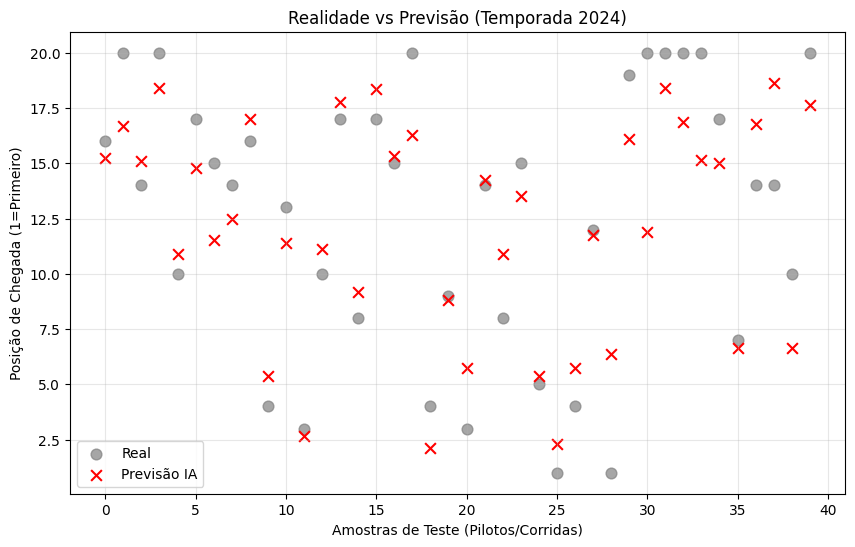

In [13]:
plt.figure(figsize=(10, 6))

# Dados reais (Eixo X apenas um índice para espalhar os pontos)
plt.scatter(range(len(y_test)), y_test, color='gray', label='Real', alpha=0.7, s=60)

# Previsões da IA
plt.scatter(range(len(y_test)), pred_otimizada, color='red', label='Previsão IA', marker='x', s=60)

plt.title('Realidade vs Previsão (Temporada 2024)')
plt.xlabel('Amostras de Teste (Pilotos/Corridas)')
plt.ylabel('Posição de Chegada (1=Primeiro)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()